# **Feature Extraction and Price Prediction for Mobile Phones**

## IMPORT LIBRARIES

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## LOAD THE DATASET

In [94]:
df = pd.read_csv(
    r"C:\Users\aarti\OneDrive\Documents\mobile_phone_Project_4.csv",
    encoding="cp1252"
)

df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [95]:
df.shape

(541, 12)

### Insight:
* The dataset contains 541 mobile-phone records and 12 features.

In [96]:
df.columns

Index(['Unnamed: 0', 'Model', 'Colour', 'Memory', 'RAM', 'Battery_',
       'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_',
       'Prize'],
      dtype='str')

# 📋 Data Overview

* Imported the **mobile phone dataset** from a CSV file for analysis.
* Examined the dataset to understand its **structure, records, and available features**.
* The dataset contains information about different **mobile phone models**, including their specifications and corresponding prices.
* Important attributes include **model, colour, memory, RAM, battery capacity, camera, AI lens, processor, and price**.
* The dataset will be analyzed further to discover **patterns, trends, and relationships between mobile phone specifications and their prices**.


In [97]:
df.rename(columns={'Unnamed: 0': ''}, inplace=True)
df.set_index('', inplace=True)
df.head(5)

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
,,,,,,,,,,,
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


## 📌 Dataset Index

* The **`Unnamed: 0`** column represents the index number assigned to each row in the dataset.
* This column was automatically added when the DataFrame was exported to a CSV file along with its index.
* It does not provide any useful information about the mobile phone records.
* Therefore, the **`Unnamed: 0`** column can be deleted before performing further analysis.




In [98]:
df.shape

(541, 11)

Now the dataset contains **541 rows and 11 columns**

In [99]:
# Reassign back to df to save changes
df = df.rename(columns={
    'Battery_': 'Battery_Level',
    'Processor_': 'Processor_Type'
})

## Renaming Column Headers

Action Taken: Updated ambiguous column names to standardize the dataset.

* Changed Battery_ to Battery_Level

* Changed Processor_ to Processor_Type

Purpose: Removes confusing trailing underscores and replaces them with clear, standard terminology.

In [100]:
# Convert specifications and price into numeric types safely
df['Front Camera'] = pd.to_numeric(
    df['Front Camera'].astype(str).str.extract(r'(\d+)')[0], 
    errors='coerce'
)

df['Rear Camera'] = pd.to_numeric(
    df['Rear Camera'].astype(str).str.extract(r'(\d+)')[0], 
    errors='coerce'
)

df['Prize'] = pd.to_numeric(
    df['Prize'].astype(str).str.replace(r'[^\d.]', '', regex=True), 
    errors='coerce'
)

In [101]:
df.info()

<class 'pandas.DataFrame'>
Index: 541 entries, 0 to 642
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Model           541 non-null    str    
 1   Colour          541 non-null    str    
 2   Memory          541 non-null    int64  
 3   RAM             541 non-null    int64  
 4   Battery_Level   541 non-null    int64  
 5   Rear Camera     541 non-null    int64  
 6   Front Camera    541 non-null    int64  
 7   AI Lens         541 non-null    int64  
 8   Mobile Height   541 non-null    float64
 9   Processor_Type  541 non-null    str    
 10  Prize           541 non-null    int64  
dtypes: float64(1), int64(7), str(3)
memory usage: 50.7 KB


## Modifying Column Data Types

Action Taken: Cast categorical text entries into correct numeric data types for numerical operations.

* Front Camera and Rear Camera: Changed from string format to integer (int64).

* Prize: Converted text to numeric integer (int64).

Purpose: Ensures columns containing numerical metrics are properly categorized for computation rather than treated as plain text strings.


In [102]:
print("Columns                       null values")
for column in df.columns:
    print(f"{column:<30}: {df[column].isnull().sum()}")

Columns                       null values
Model                         : 0
Colour                        : 0
Memory                        : 0
RAM                           : 0
Battery_Level                 : 0
Rear Camera                   : 0
Front Camera                  : 0
AI Lens                       : 0
Mobile Height                 : 0
Processor_Type                : 0
Prize                         : 0


## Null Value Inspection

* Action Taken: Evaluated the dataset for incomplete entries or missing fields.

* Result: Every column returned a count of 0 null entries.

* Outcome: No data filling (imputation) or row removal techniques are needed.

In [103]:
# Select numerical columns from DataFrame
numeric_cols = df.select_dtypes(include='number').columns

outlier_results = []

for col in numeric_cols:
    # Calculate 1st and 3rd quartiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Calculate Interquartile Range
    IQR = Q3 - Q1
    
    # Define upper and lower bounds for outliers
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    # Count total outliers in the column
    outlier_count = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()
    
    # Append results to the list
    outlier_results.append({
        'Feature': col,
        'Outlier Count': outlier_count
    })

# Convert results into DataFrame
outlier_df = pd.DataFrame(outlier_results)

# Display the result
outlier_df

,Feature,Outlier Count
0,Memory,55
1,RAM,0
2,Battery_Level,152
3,Rear Camera,39
4,Front Camera,13
5,AI Lens,34
6,Mobile Height,33
7,Prize,25


## Identifying Outliers across Features

* Taken: Executed an Interquartile Range (IQR) detection process across all quantitative features to measure extreme data distributions.

* Findings: Outlier points were detected across various phone specifications:

  * Battery_Level: 152 extreme entries

  * Memory: 55 extreme entries

  * Rear Camera: 39 extreme entries

  * AI Lens: 34 extreme entries

  * Mobile Height: 33 extreme entries

  * Prize (Price): 25 extreme entries

  * Front Camera: 13 extreme entries

In [104]:
skewness = df[numeric_cols].skew()
kurtosis = df[numeric_cols].kurtosis()

def skewness_type(value):
    if value > 1:
        return 'Highly Right-Skewed'
    elif value > 0.5:
        return 'Moderately Right-Skewed'
    elif value < -1:
        return 'Highly Left-Skewed'
    elif value < -0.5:
        return 'Moderately Left-Skewed'
    else:
        return 'Approximately Symmetric'

def kurtosis_type(value):
    if value > 0:
        return 'Leptokurtic'
    elif value < 0:
        return 'Platykurtic'
    else:
        return 'Mesokurtic'

skew_kurt_df = pd.DataFrame({
    'Feature': numeric_cols,
    'Skewness': skewness.values,
    'Skewness Type': skewness.apply(skewness_type).values,
    'Kurtosis': kurtosis.values,
    'Kurtosis Type': kurtosis.apply(kurtosis_type).values
})

skew_kurt_df[['Skewness', 'Kurtosis']] = (
    skew_kurt_df[['Skewness', 'Kurtosis']].round(2)
)

skew_kurt_df

,Feature,Skewness,Skewness Type,Kurtosis,Kurtosis Type
0,Memory,1.03,Highly Right-Skewed,0.86,Leptokurtic
1,RAM,0.07,Approximately Symmetric,-1.31,Platykurtic
2,Battery_Level,-3.30,Highly Left-Skewed,14.75,Leptokurtic
3,Rear Camera,1.80,Highly Right-Skewed,7.23,Leptokurtic
4,Front Camera,2.49,Highly Right-Skewed,8.76,Leptokurtic
5,AI Lens,3.61,Highly Right-Skewed,11.09,Leptokurtic
6,Mobile Height,1.17,Highly Right-Skewed,48.22,Leptokurtic
7,Prize,2.43,Highly Right-Skewed,9.61,Leptokurtic


## 🔍 Core Takeaways

* Non-Normal Distributions: The majority of quantitative features depart significantly from a bell-curve (normal) distribution.

* Symmetry in RAM: RAM stands out as the lone feature exhibiting an approximately balanced, symmetric spread.

* Presence of Heavy Outliers: Battery_Level, Mobile Height, and Prize display pronounced tail thickness and heavy concentration of extreme values.

* Preprocessing Requirements: High skewness and elevated kurtosis signal a need for data transformation (e.g., log/box-cox) or explicit outlier mitigation prior to model training.

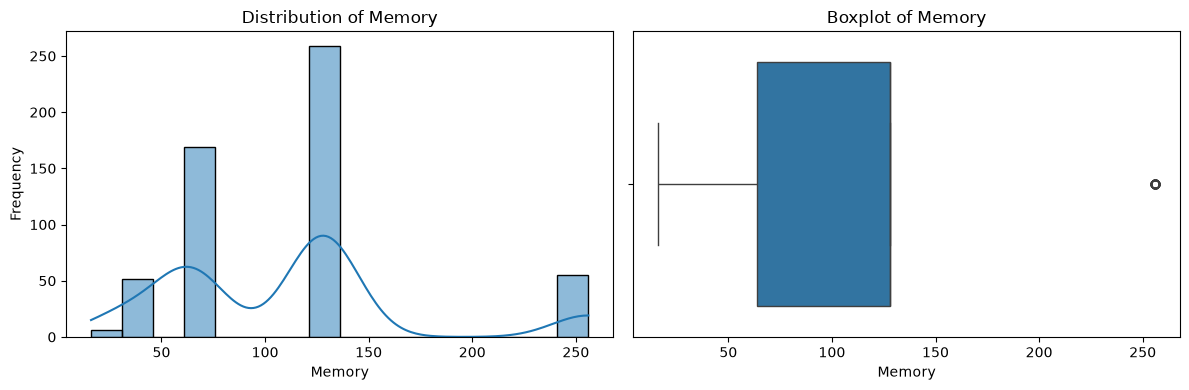

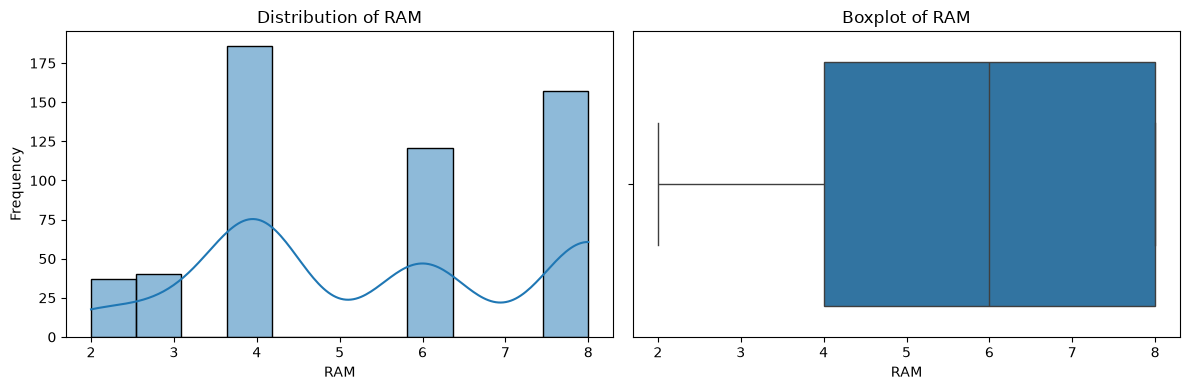

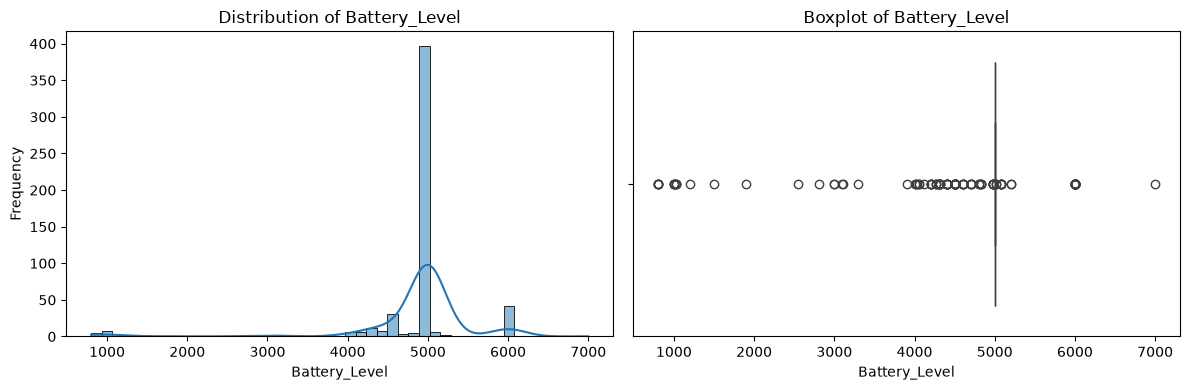

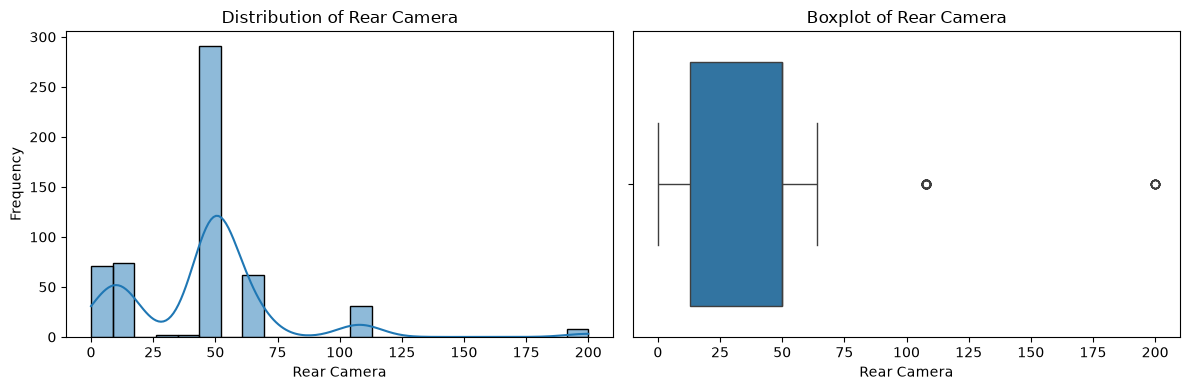

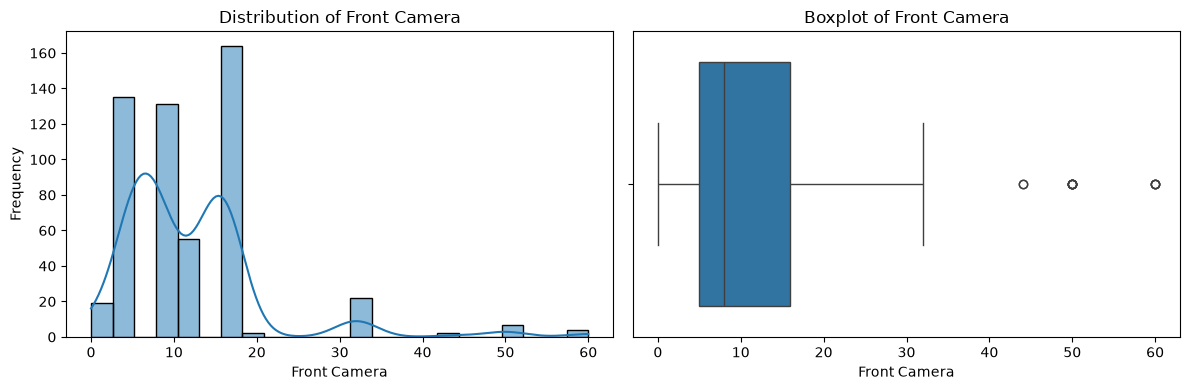

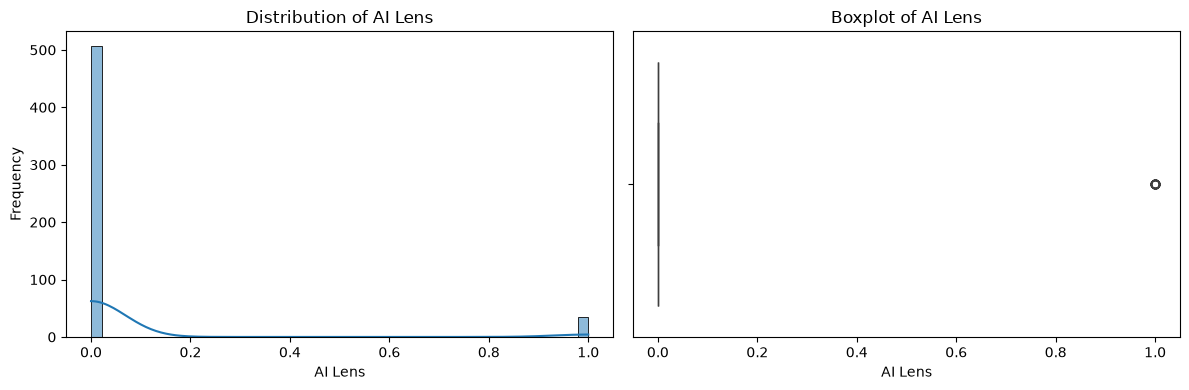

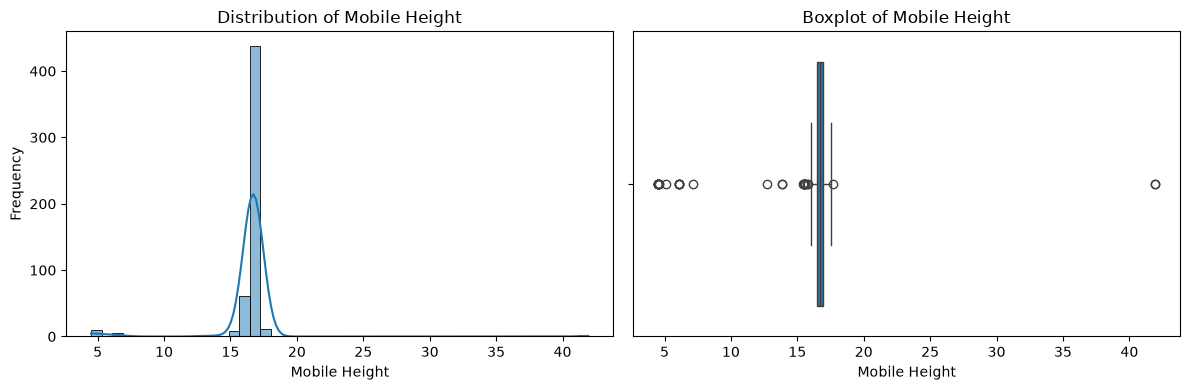

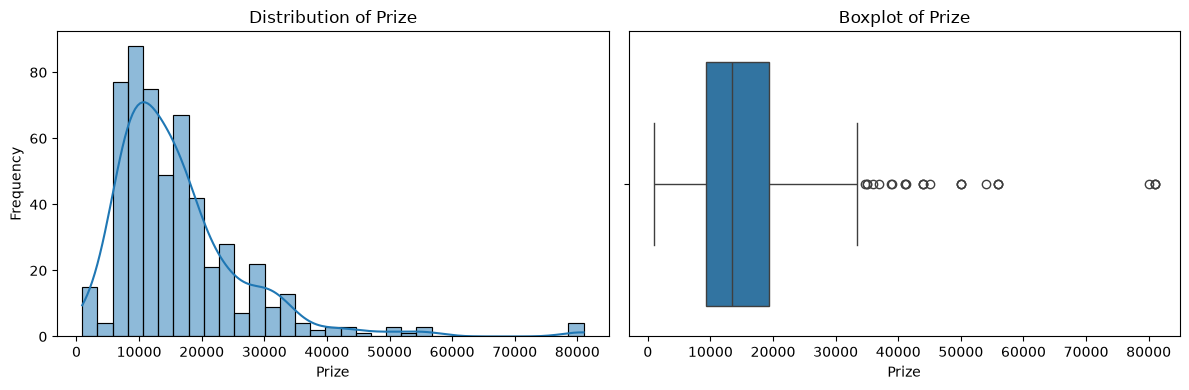

In [105]:
for col in numeric_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE
    sns.histplot(data=df, x=col, kde=True, ax=ax1)
    ax1.set(title=f'Distribution of {col}', xlabel=col, ylabel='Frequency')
    
    # Boxplot
    sns.boxplot(data=df, x=col, ax=ax2)
    ax2.set(title=f'Boxplot of {col}', xlabel=col)
    
    plt.tight_layout()
    plt.show()

C:\Users\aarti\AppData\Local\Temp\ipykernel_25344\1256622996.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object', 'category']):


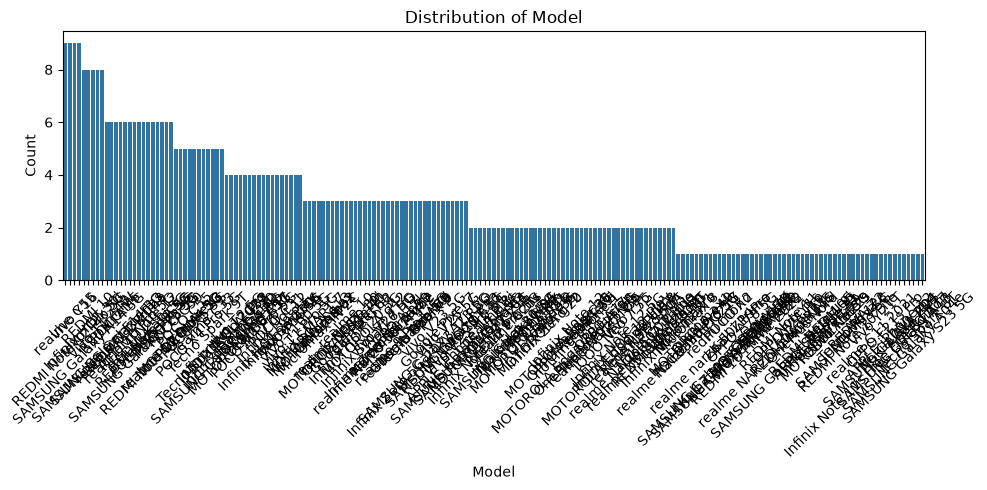

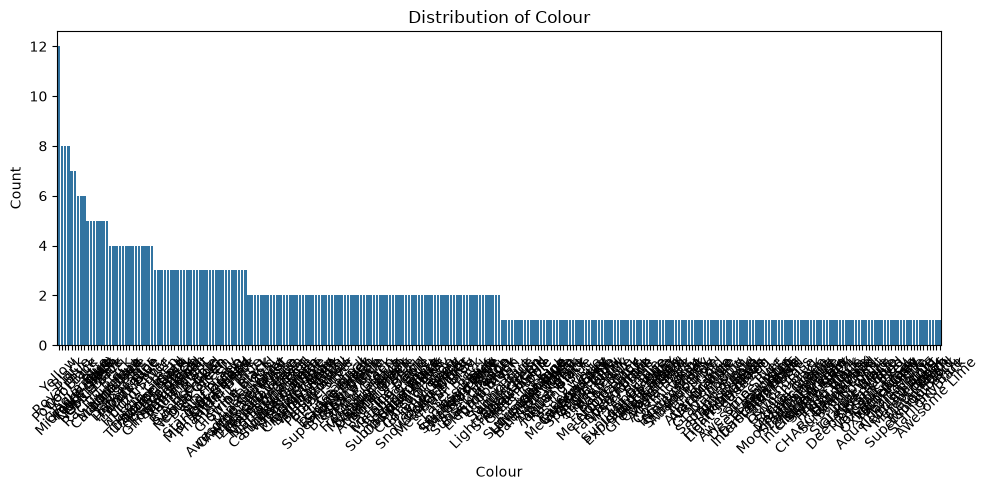

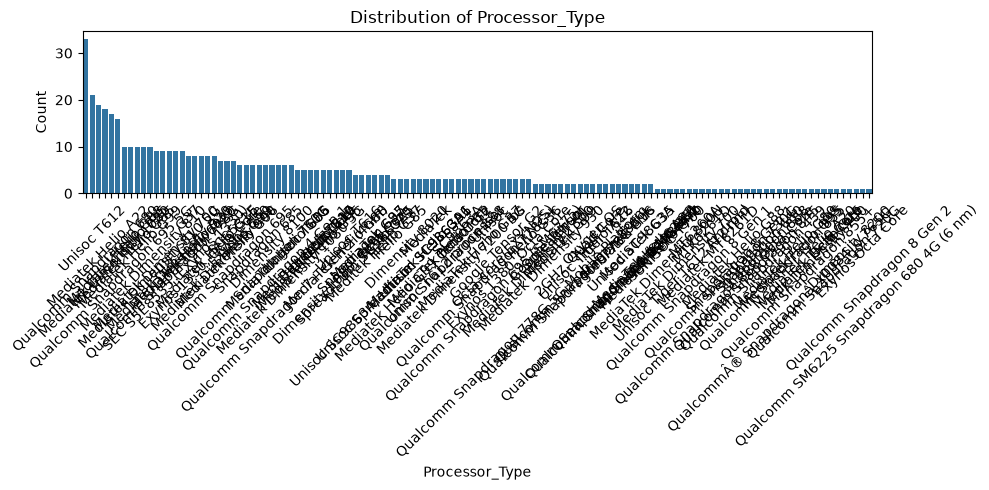

In [106]:
#  Clean Vertical Countplot
for col in df.select_dtypes(include=['object', 'category']):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    sns.countplot(
        data=df, 
        x=col, 
        order=df[col].value_counts().index, 
        ax=ax
    )
    
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

C:\Users\aarti\AppData\Local\Temp\ipykernel_25344\2597265354.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


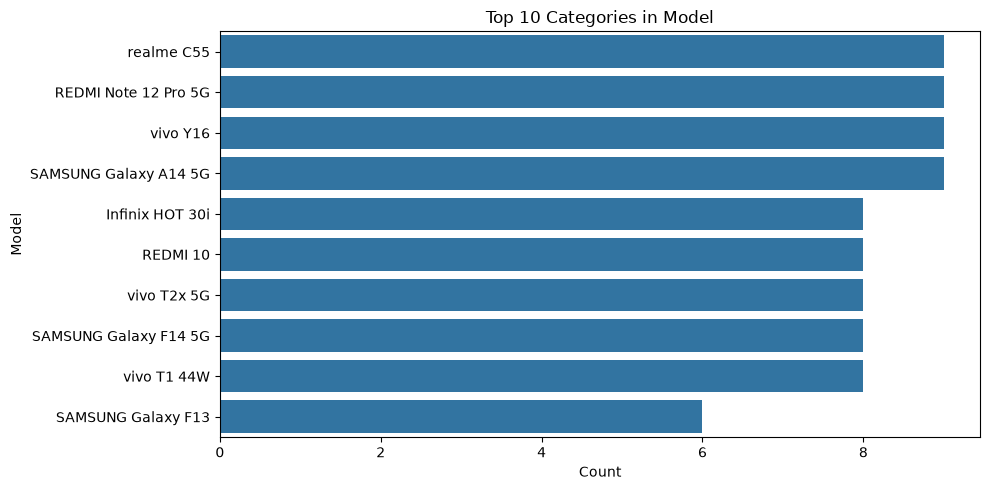

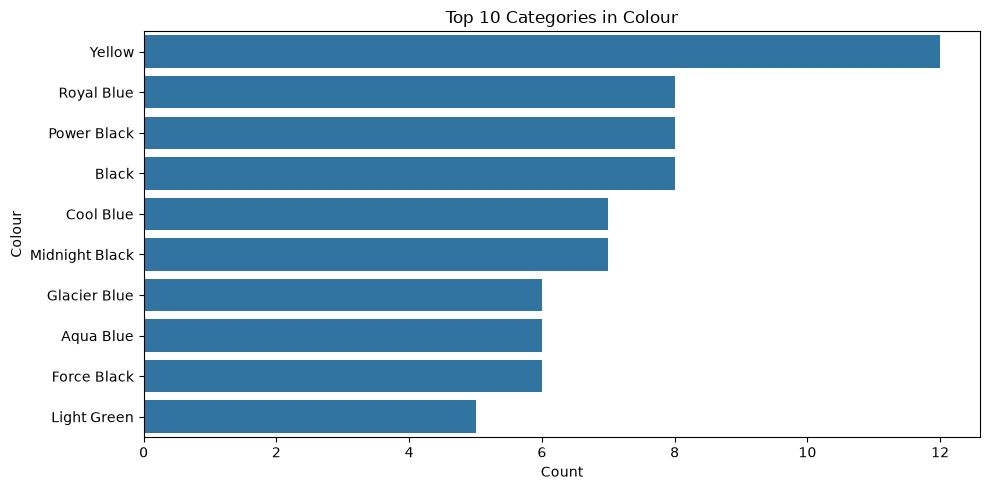

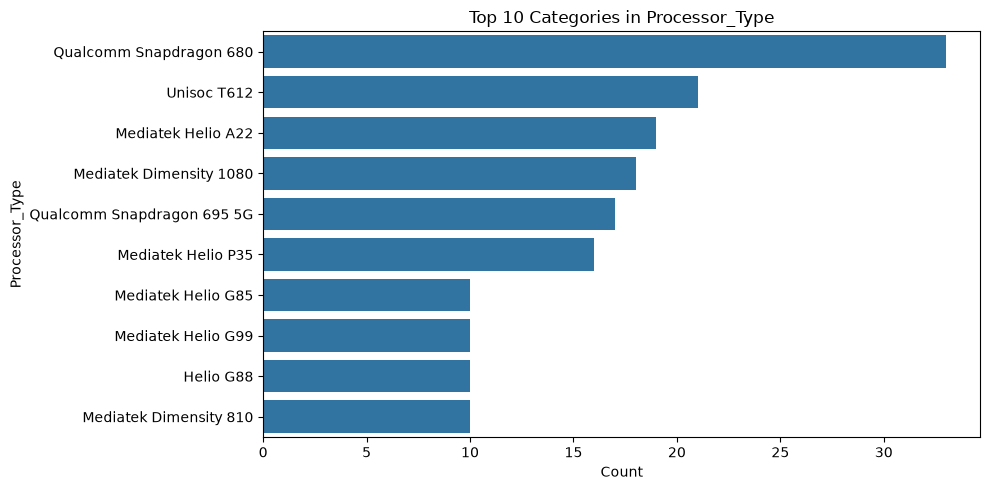

In [107]:
# Define categorical columns first
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Now run your loop
for col in categorical_cols:
    top_10 = df[col].value_counts().nlargest(10)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=top_10.values, y=top_10.index, ax=ax)

    ax.set_title(f'Top 10 Categories in {col}')
    ax.set_xlabel('Count')
    ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()

## Key Findings: Sales & Categorical Trends

* Leading Models: Popular devices like the Realme C55, Redmi Note 12 Pro 5G, and Vivo Y16 dominate sales volume across the catalog.

* Color Choice: Yellow emerges as the single most frequent buyer selection among color variants.

* Chipset Dominance: Qualcomm Snapdragon 680 leads as the primary processor choice, reflecting high market demand for mid-range chipsets.

In [108]:
continuous_cols = [
    'Memory', 'RAM', 'Battery_Level', 
    'Rear Camera', 'Front Camera', 'Mobile Height', 'Prize'
]

def cap_outliers_iqr(df, col):
    q25, q75 = df[col].quantile([0.25, 0.75])
    iqr = q75 - q25
    
    if iqr == 0:
        print(f"Skipped {col}: IQR = 0")
        return df[col]
        
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    
    return df[col].clip(lower=lower_bound, upper=upper_bound)

for col in continuous_cols:
    df[col] = cap_outliers_iqr(df, col)

print("IQR capping completed successfully.")

Skipped Battery_Level: IQR = 0
IQR capping completed successfully.


## 🔧 Outlier 
* TreatmentMethodology: Managed extreme values across continuous numerical variables using Interquartile Range (IQR) Winsorization/Capping.
* Threshold Calculation: Boundaries were defined using standard $1.5 \times \text{IQR}$ upper and lower fences.
* Boundary Clipping: Outliers extending past these limits were clipped to the maximum or minimum acceptable thresholds rather than dropped.
* Data Retention: Preserved the full sample size (541 rows) without removing any records or compromising statistical power.
* Feature Scope: Applied exclusively to continuous numerical metrics; all categorical and binary attributes were bypassed.

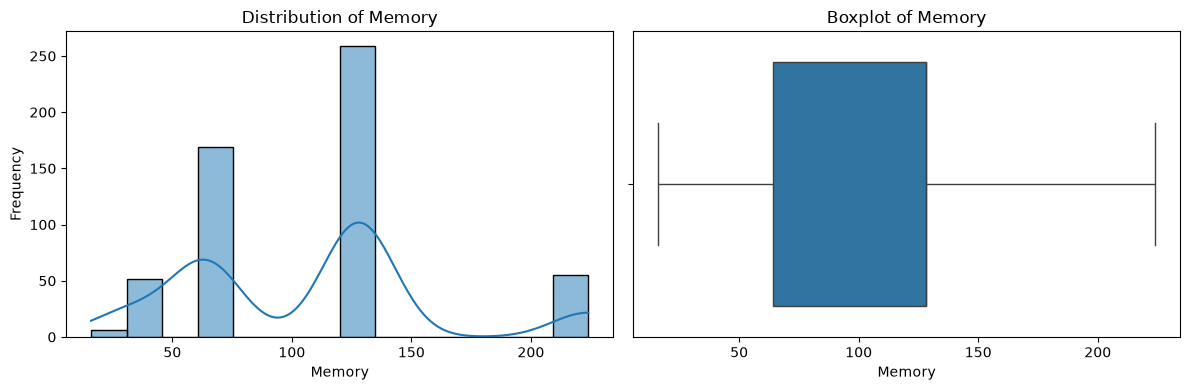

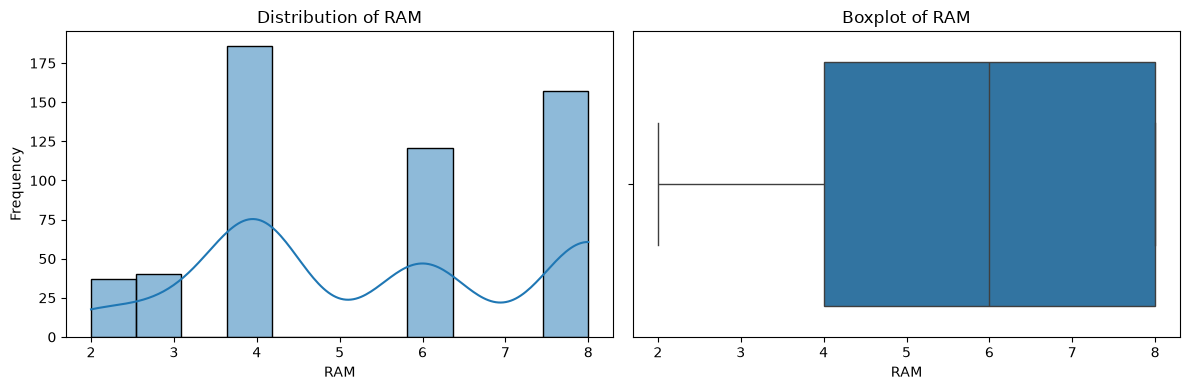

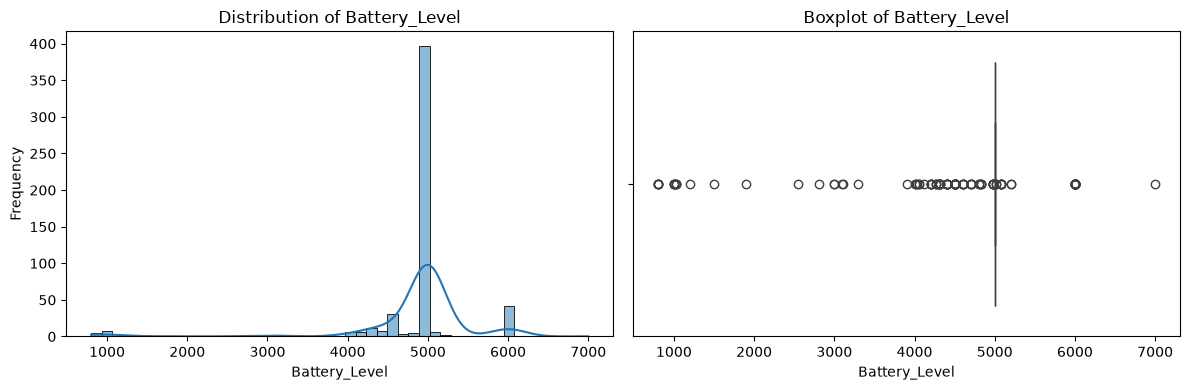

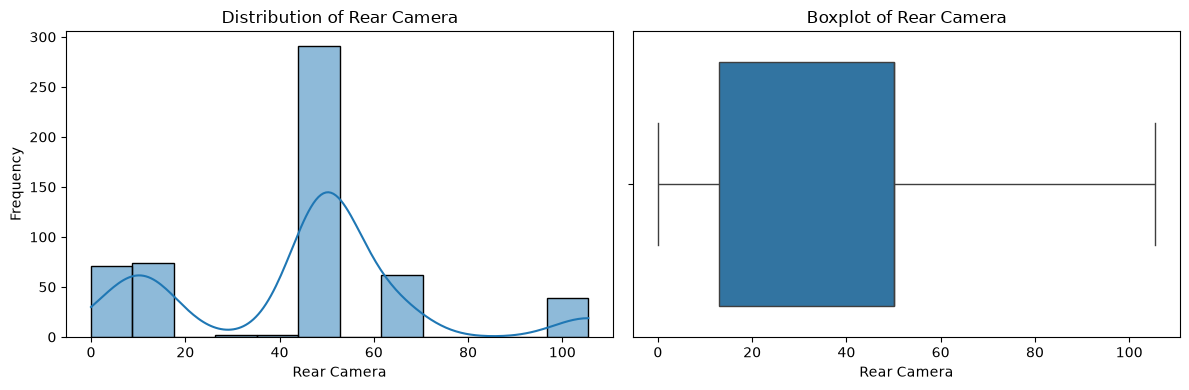

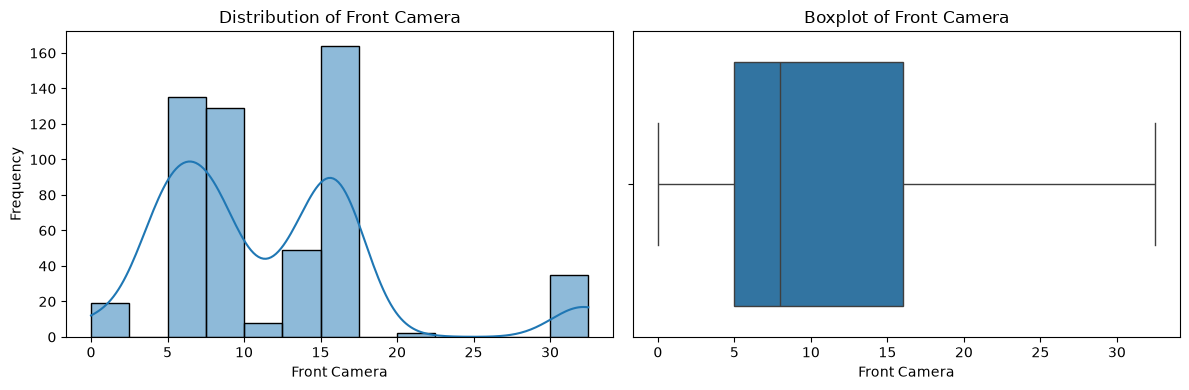

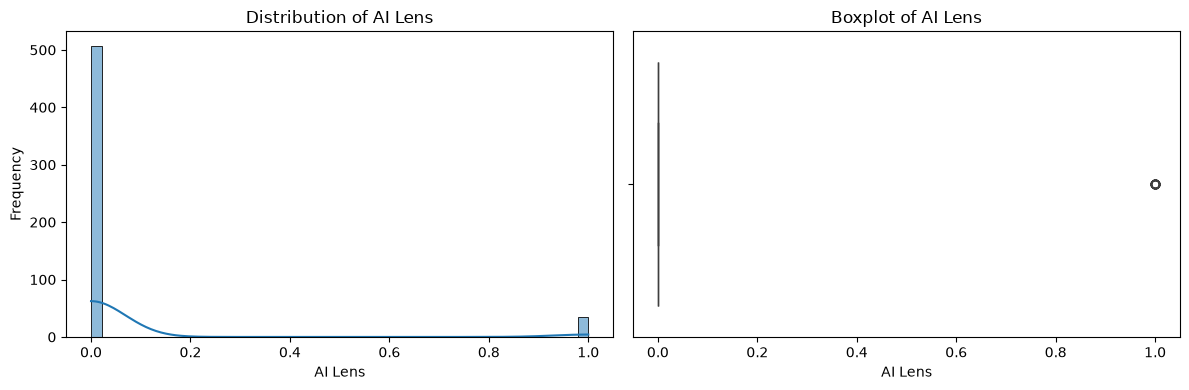

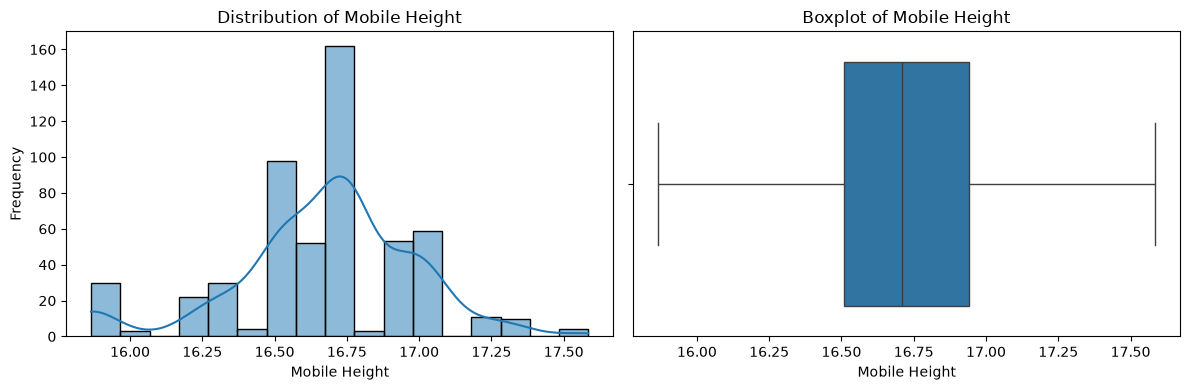

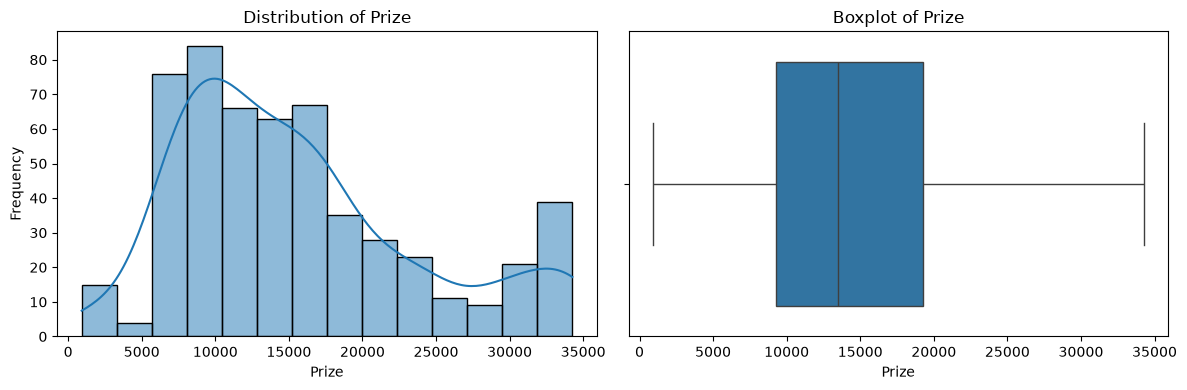

In [109]:
for col in numeric_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram + KDE
    sns.histplot(data=df, x=col, kde=True, ax=ax1)
    ax1.set(title=f'Distribution of {col}', xlabel=col, ylabel='Frequency')

    # Boxplot
    sns.boxplot(data=df, x=col, ax=ax2)
    ax2.set(title=f'Boxplot of {col}', xlabel=col)

    plt.tight_layout()
    plt.show()

In [110]:
# Calculate location index
target_idx = df.columns.get_loc('Front Camera') + 1

# Compute total sum and insert
total_mp = df['Rear Camera'].add(df['Front Camera'])
df.insert(target_idx, 'Total Camera MP', total_mp)

## 🏷️ Feature Extraction

* New Derived Feature: Created Total_Camera_MP to quantify total imaging capability.

* Calculation: Computed as the arithmetic sum of Front Camera and Rear Camera resolution specs.

* Purpose: Represents the overall megapixel capacity of a device in a single continuous attribute.

* Utility: Provides a unified metric for comparing overall camera hardware specs across different phone models.

In [111]:
# Insert 'Brand' immediately after the 'Model' column
df.insert(
    loc=df.columns.get_loc('Model') + 1,
    column='Brand',
    value=df['Model'].str.split().str[0]
)

## 🏷️ Feature Extraction

* New Brand Feature: Parsed out a standalone Brand variable directly from the full Model string.

* Extraction Logic: Isolated the leading word of each model designation to capture manufacturer identity.

* Analytical Value: Enables aggregated brand-level performance modeling and market comparison.

In [112]:
# Insert 'Processor Brand' immediately after 'Processor_Type'
df.insert(
    loc=df.columns.get_loc('Processor_Type') + 1,
    column='Processor Brand',
    value=df['Processor_Type'].str.split().str[0]
)

## 🏷️ Feature Extraction Text Variation

* Processor Brand Isolation: Parsed the Processor_Brand column from the Processor_Type field.

* Extraction Logic: Selected the initial word of the chipset name to represent the underlying manufacturer.

* Analytical Purpose: Facilitates comparative analysis and benchmarking across various CPU brands.

In [113]:
# Compute ratio using pandas div method
df['Battery per GB'] = df['Battery_Level'].div(df['RAM'])

## 🏷️ Feature Extraction Text Variation

* New Derived Feature: Added Battery_per_GB to assess energy-to-memory efficiency.

* Computation Logic: Calculated by taking the ratio of Battery_Level to RAM.

* Interpretation: Measures the amount of battery capacity allocated for each gigabyte of system memory.

* Analytical Value: Helps evaluate hardware balancing and efficiency tradeoffs across smartphone models.

In [114]:
# Compute storage-to-RAM ratio using vector division
df['Memory per GB'] = df['Memory'].div(df['RAM'])

## 🏷️ Feature Extraction Text Variation

* New Ratio Feature: Constructed Memory_per_GB to represent internal storage scaling relative to system memory.

* Calculation: Derived by dividing overall storage (Memory) by working memory (RAM).

* Interpretation: Indicates the proportion of internal ROM space available per unit of RAM.

* Analytical Value: Helps evaluate hardware configuration balances across different device price points.

In [115]:
# Define classification rules in a central dictionary
phone_specs = {
    'Gaming Phone': (
        (df['RAM'] >= 8) & 
        (df['Battery_Level'] >= 5000) & 
        (df['Processor_Type'].astype(str).str.contains('Snapdragon|Dimensity|Helio G', case=False, na=False))
    ),
    'Camera Phone': (df['Rear Camera'] >= 64) & (df['Front Camera'] >= 16),
    'Performance Phone': df['RAM'] >= 8,
    'Budget Phone': df['Prize'] <= 10000
}

# Apply definitions in loop
for col_name, condition in phone_specs.items():
    df[col_name] = condition.astype(int)

## 📊 Phone Classification & Market SegmentationCreated 
### Custom categorical dimensions to categorize devices according to specification tiers and cost brackets:
* 🎮 Gaming Phone: Targeted at high-end mobile gaming using strict criteria (RAM $\ge$ 8GB, battery $\ge$ 5000mAh, and specialized gaming chipsets).
* 📸 Camera Phone: Flagged for advanced photography based on primary ($\ge$ 64MP) and front ($\ge$ 16MP) sensor specs.
* ⚡ Performance Phone: Captures power-user devices with elevated operational memory ($\ge$ 8GB RAM).
* 💰 Budget Phone: Highlights entry-level tier smartphones priced at or under ₹10,000.
### These features enable structured analysis of price-to-performance distribution across distinct consumer categories.

In [116]:
# Bin prices directly into functional market tiers
df.insert(
    loc=df.columns.get_loc('Prize') + 1,
    column='Price Segment',
    value=pd.cut(
        x=df['Prize'], 
        bins=[-1, 10000, 20000, float('inf')], 
        labels=['Budget', 'Mid-Range', 'Premium']
    )
)

## 💰 Key Insights – Price Segmentation

### 🏷️ Categorical Binning: Introduced Price Segment to partition smartphone models into structured economic tiers based on retail pricing.

* Budget Tier: Bounded between ₹0 and ₹10,000.

* Mid-Range Tier: Covers the ₹10,000 to ₹20,000 price point.

* Premium Tier: Consists of flagship devices priced above ₹20,000.

### 🔍 Analytical Value: Enables cross-tier comparison and multivariate exploration (e.g., assessing RAM, storage, CPU, and battery allocation across distinct price bands).

In [117]:
df.head(10)

,Model,Brand,Colour,Memory,RAM,Battery_Level,Rear Camera,Front Camera,Total Camera MP,AI Lens,...,Processor_Type,Processor Brand,Prize,Price Segment,Battery per GB,Memory per GB,Gaming Phone,Camera Phone,Performance Phone,Budget Phone
,,,,,,,,,,,,,,,,,,,,,
0,Infinix SMART 7,Infinix,Night Black,64,4,6000,13.0,5.0,18.0,1,...,Unisoc Spreadtrum SC9863A1,Unisoc,7299,Budget,1500.0,16.0,0,0,0,1
1,Infinix SMART 7,Infinix,Azure Blue,64,4,6000,13.0,5.0,18.0,1,...,Unisoc Spreadtrum SC9863A1,Unisoc,7299,Budget,1500.0,16.0,0,0,0,1
2,MOTOROLA G32,MOTOROLA,Mineral Gray,128,8,5000,50.0,16.0,66.0,0,...,Qualcomm Snapdragon 680,Qualcomm,11999,Mid-Range,625.0,16.0,1,0,1,0
3,POCO C50,POCO,Royal Blue,32,2,5000,8.0,5.0,13.0,0,...,Mediatek Helio A22,Mediatek,5649,Budget,2500.0,16.0,0,0,0,1
4,Infinix HOT 30i,Infinix,Marigold,128,8,5000,50.0,5.0,55.0,1,...,G37,G37,8999,Budget,625.0,16.0,0,0,1,1
5,Infinix HOT 30i,Infinix,Glacier Blue,128,8,5000,50.0,5.0,55.0,1,...,G37,G37,8999,Budget,625.0,16.0,0,0,1,1
6,Infinix HOT 30i,Infinix,Mirror Black,128,8,5000,50.0,5.0,55.0,1,...,G37,G37,8999,Budget,625.0,16.0,0,0,1,1
7,Infinix HOT 30i,Infinix,Diamond White,128,8,5000,50.0,5.0,55.0,1,...,G37,G37,8999,Budget,625.0,16.0,0,0,1,1
8,Infinix HOT 30i,Infinix,Diamond White,64,4,5000,50.0,5.0,55.0,1,...,G37,G37,7999,Budget,1250.0,16.0,0,0,0,1


## 📊 Summary of Feature Engineering Tiers

* Dataset Expansion: Following targeted feature extraction and transformation, the total attribute count expanded from 11 to 21 columns.

* Engineered Metrics: Introduced domain-specific dimensions covering manufacturer identity, hardware ratios (Battery-to-RAM, Storage-to-RAM), camera configurations, usage-based personas, and price tiers.

* Downstream Utility: The augmented feature set delivers richer signal for EDA, comparative analysis, and downstream predictive modeling.

In [118]:
df.describe().round(2)

,Memory,RAM,Battery_Level,Rear Camera,Front Camera,Total Camera MP,AI Lens,Mobile Height,Prize,Battery per GB,Memory per GB,Gaming Phone,Camera Phone,Performance Phone,Budget Phone
count,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00
mean,107.30,5.40,4871.59,44.57,11.52,56.09,0.06,16.68,15499.80,1067.64,20.21,0.16,0.16,0.29,0.33
std,53.09,1.98,780.15,25.67,7.23,30.36,0.24,0.32,8234.75,521.91,9.84,0.36,0.36,0.45,0.47
min,16.00,2.00,800.00,0.00,0.00,0.00,0.00,15.87,920.00,100.00,2.00,0.00,0.00,0.00,0.00
25%,64.00,4.00,5000.00,13.00,5.00,21.00,0.00,16.51,9290.00,625.00,16.00,0.00,0.00,0.00,0.00
50%,128.00,6.00,5000.00,50.00,8.00,58.00,0.00,16.71,13499.00,833.33,16.00,0.00,0.00,0.00,0.00
75%,128.00,8.00,5000.00,50.00,16.00,66.00,0.00,16.94,19280.00,1250.00,21.33,0.00,0.00,1.00,1.00
max,224.00,8.00,7000.00,105.50,32.50,138.00,1.00,17.58,34265.00,2500.00,112.00,1.00,1.00,1.00,1.00


## 🔎 Primary Dataset Insights

* Dominant Hardware Profile: Typical configurations center around 128 GB ROM, 4–8 GB RAM, and standard 5,000 mAh battery capacities.

* Segment Distribution: Specialized devices (gaming and photography flagships) represent a minority, whereas entry-tier and performance-centric models make up the largest market share.

In [119]:
from sklearn.preprocessing import LabelEncoder

# Brand Encoding
brand_le = LabelEncoder()
df['Brand'] = brand_le.fit_transform(df['Brand'])

# Processor Brand Encoding
processor_le = LabelEncoder()
df['Processor Brand'] = processor_le.fit_transform(df['Processor Brand'])

## 🔢 Categorical Encoding Strategy

* Target Variables: Executed label encoding on Brand and Processor Brand to convert string categories into discrete numeric identifiers.

* Numeric Representation: Assigns an integer index to each unique string value, removing non-numeric text columns.

* ML Readiness: Prepares raw categorical values for tree-based algorithms and linear estimators that require numerical matrix inputs.

In [120]:
df.head()

,Model,Brand,Colour,Memory,RAM,Battery_Level,Rear Camera,Front Camera,Total Camera MP,AI Lens,...,Processor_Type,Processor Brand,Prize,Price Segment,Battery per GB,Memory per GB,Gaming Phone,Camera Phone,Performance Phone,Budget Phone
,,,,,,,,,,,,,,,,,,,,,
0,Infinix SMART 7,4,Night Black,64,4,6000,13.0,5.0,18.0,1,...,Unisoc Spreadtrum SC9863A1,29,7299,Budget,1500.0,16.0,0,0,0,1
1,Infinix SMART 7,4,Azure Blue,64,4,6000,13.0,5.0,18.0,1,...,Unisoc Spreadtrum SC9863A1,29,7299,Budget,1500.0,16.0,0,0,0,1
2,MOTOROLA G32,6,Mineral Gray,128,8,5000,50.0,16.0,66.0,0,...,Qualcomm Snapdragon 680,20,11999,Mid-Range,625.0,16.0,1,0,1,0
3,POCO C50,11,Royal Blue,32,2,5000,8.0,5.0,13.0,0,...,Mediatek Helio A22,14,5649,Budget,2500.0,16.0,0,0,0,1
4,Infinix HOT 30i,4,Marigold,128,8,5000,50.0,5.0,55.0,1,...,G37,6,8999,Budget,625.0,16.0,0,0,1,1


In [121]:
for number, brand in enumerate(brand_le.classes_):
    print(number, "=", brand)

0 = APPLE
1 = Google
2 = I
3 = IQOO
4 = Infinix
5 = LAVA
6 = MOTOROLA
7 = Micromax
8 = Nokia
9 = OPPO
10 = OnePlus
11 = POCO
12 = REDMI
13 = Redmi
14 = SAMSUNG
15 = Tecno
16 = itel
17 = micromax
18 = micromax1
19 = nothing
20 = realme
21 = redmi
22 = vivo


In [122]:
for number, brand in enumerate(processor_le.classes_):
    print(number, "=", brand)

0 = 0
1 = 2GHz,
2 = 6
3 = Android
4 = Dimensity
5 = Exynos
6 = G37
7 = Google
8 = Helio
9 = IOS
10 = MT6260A
11 = MTK
12 = MTK6261D
13 = MediaTek
14 = Mediatek
15 = Meditek
16 = Octa
17 = Octa-core
18 = Octa-core(EXYNOS)
19 = Oxygen
20 = Qualcomm
21 = QualcommÂ®
22 = SC6531E
23 = SC9863A
24 = SEC
25 = Snapdragon
26 = Spreadtrum
27 = Tensor
28 = UNISOC
29 = Unisoc
30 = ios
31 = snapdragon


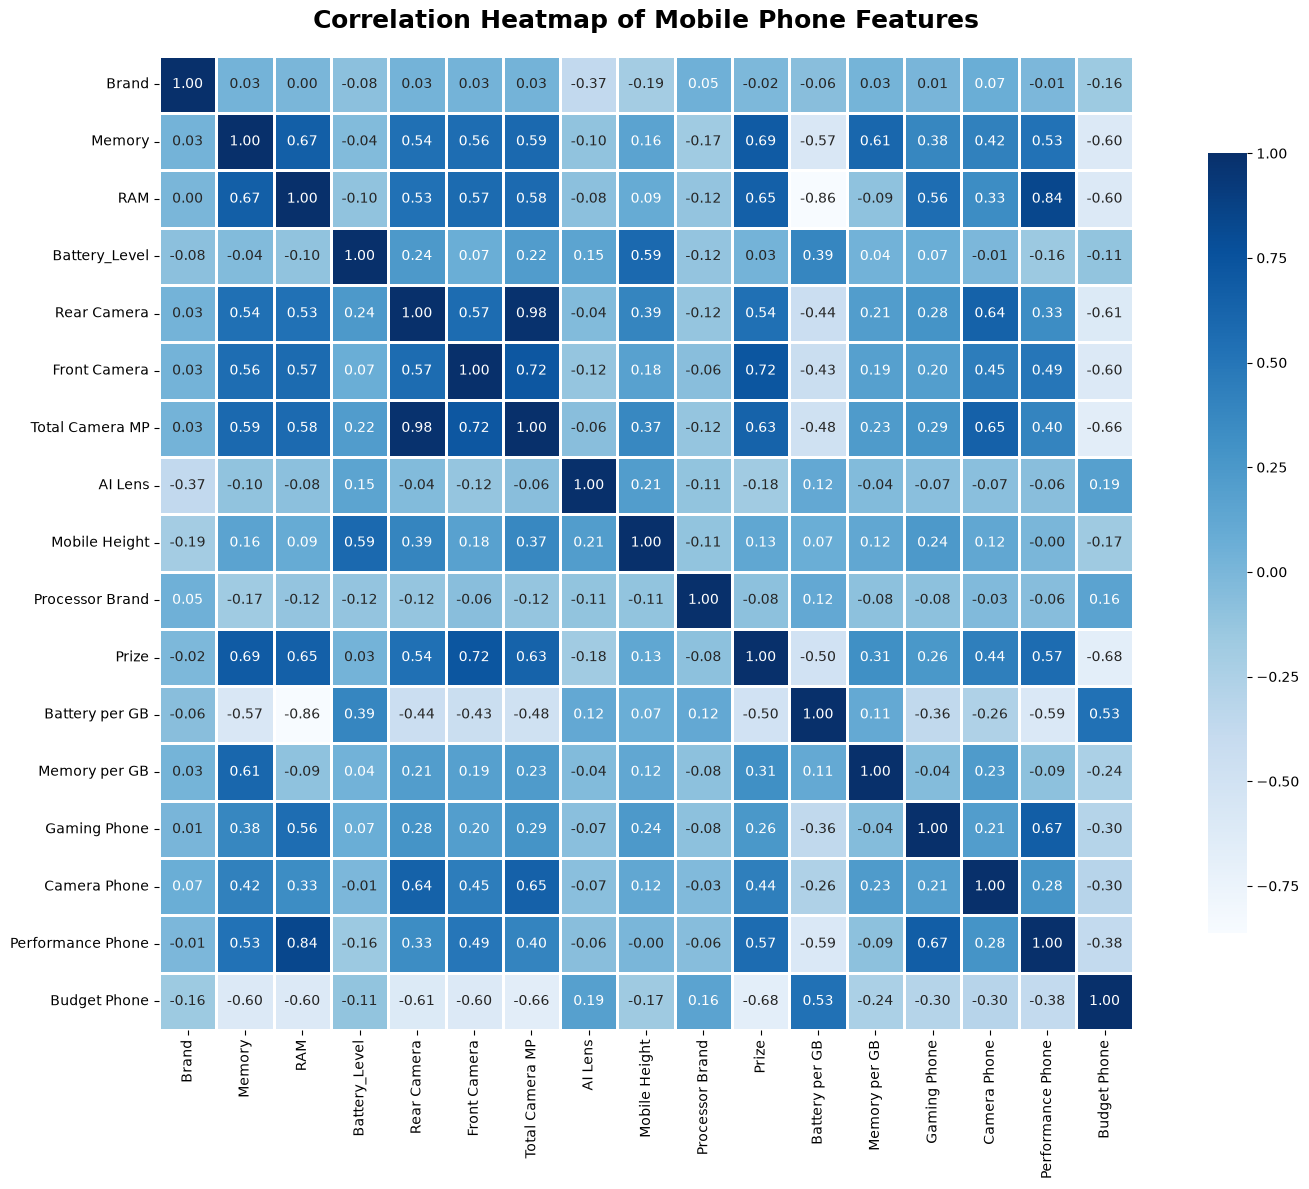

In [ ]:
# Select only numerical features for correlation calculation
numeric_cols = df.select_dtypes(include='number').columns

# Compute Pearson correlation matrix
corr_matrix = df[numeric_cols].corr()

# Set up figure dimensions
plt.figure(figsize=(16, 12))

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.8,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8}
)

# Set plot title and styling
plt.title(
    'Correlation Heatmap of Mobile Phone Features',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

## 🔗 Core Insights – Feature Correlations

* Total Camera MP vs. Rear Camera (+0.98): Near-perfect alignment, as rear camera sensor specs make up the vast majority of the calculated total megapixel count.

* Performance Phone vs. RAM (+0.84): Strong positive link driven by class definition logic, since performance tiering requires ≥8 GB RAM.

* RAM vs. Memory (+0.67): Moderate-to-strong coupling; manufacturers scale onboard storage proportionally alongside memory upgrades.

* Price Correlations:

   * Memory vs. Price (+0.69): Storage capacity serves as a primary price driver across market segments.

   * RAM vs. Price (+0.65): Higher memory configurations directly scale baseline retail cost.

   * Total Camera MP vs. Price (+0.63): Enhanced imaging systems command higher price points.

* Gaming Phone vs. Performance Phone (+0.67): Substantial overlap, as both categories target high-end hardware specifications.

* Inverse Relationships:

   * Battery per GB vs. RAM (-0.86): Strong inverse metric created because RAM forms the denominator in the  
RAM/Battery ratio.

   * Budget Phone vs. Price (-0.68): Mathematical negative correlation resulting from the ≤₹10,000 classification ceiling.

   * Budget Phone vs. Total Camera MP (-0.66): Cost-constrained tiers feature lower camera sensor counts.

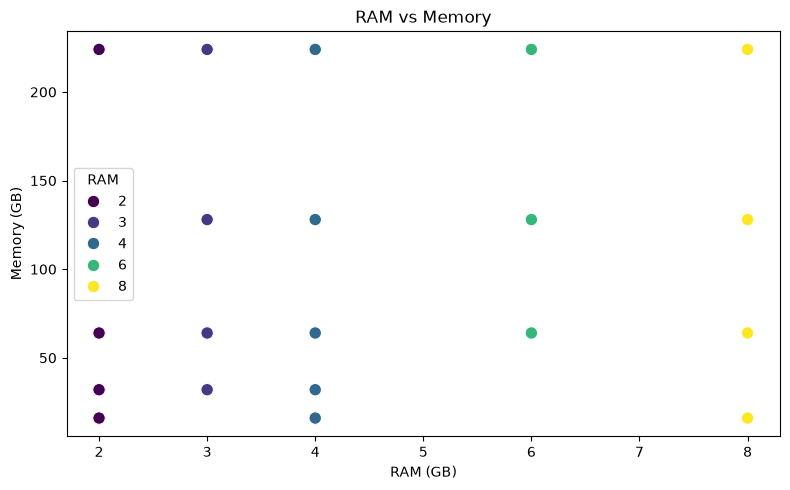

In [126]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df, x='RAM', y='Memory', 
    hue='RAM', palette='viridis', s=80, ax=ax
)

ax.set(title='RAM vs Memory', xlabel='RAM (GB)', ylabel='Memory (GB)')
plt.tight_layout()
plt.show()

## 🔍 Key Findings – RAM vs Memory
* Positive Overall Trend: RAM and internal storage exhibit a strong direct correlation, with higher-tier memory configurations scaling predictably alongside RAM capacity.

* Entry-Level Tier (2–4 GB RAM): Typically bundled with entry-level storage capacities (16 GB, 32 GB, and 64 GB).

* Mid-to-High Tier (6–8 GB RAM): Standardized around expanded storage offerings, specifically 128 GB and 256 GB.

* Premium Benchmarks: Devices featuring 8 GB+ RAM paired with 128–256 GB+ storage constitute the upper performance segment of the dataset.

* Underlying Rationale: Smartphone OEMs scale memory and storage in tandem to prevent bottlenecking multitasking performance and storage intensive applications in mid-range to flagship devices.

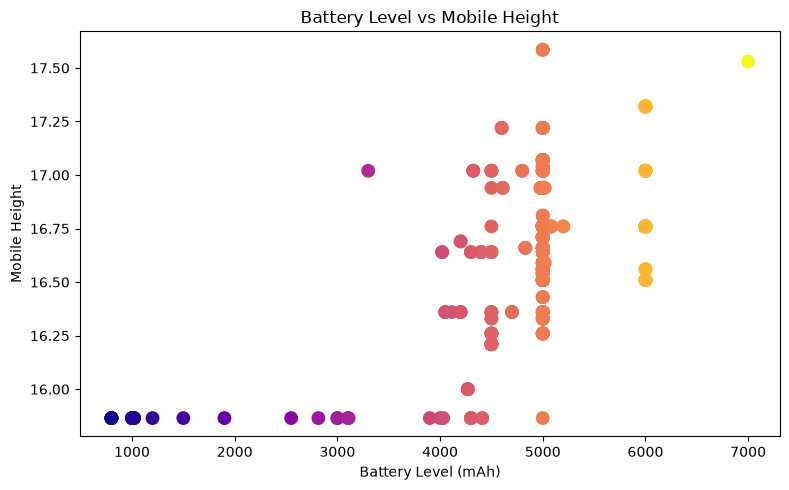

In [127]:
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    df['Battery_Level'], 
    df['Mobile Height'], 
    c=df['Battery_Level'], 
    cmap='plasma', 
    s=80
)

ax.set(
    title='Battery Level vs Mobile Height',
    xlabel='Battery Level (mAh)',
    ylabel='Mobile Height'
)

plt.tight_layout()
plt.show()

## 🔍 Key Findings – Battery Level vs. Mobile Height
* Weak Structural Correlation: Battery capacity and total mobile height show minimal linear dependency, indicating physical smartphone height is not the primary constraint for fitting larger batteries.

* Compact High-Density Devices: Multiple models feature large battery capacities (≥5000 mAh) without proportional increases in height, driven by advances in battery thickness and internal component layout.

* Standardized Heights: Smartphone heights cluster tightly around industry-standard form factors regardless of whether the battery rating is entry-level (3000–4000 mAh) or high-capacity (5000–6000 mAh).

* Underlying Rationale: Manufacturers primarily adjust internal depth (device thickness) and battery layer density to expand mAh capacity rather than stretching overall screen height or chassis length.

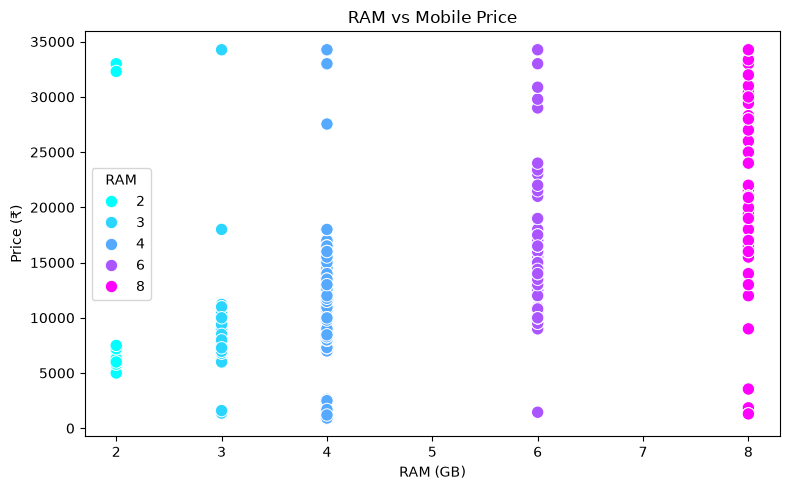

In [129]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='RAM',
    y='Prize',  # Or 'Price' depending on your column name
    hue='RAM',
    palette='cool',
    s=80,
    ax=ax
)

ax.set(
    title='RAM vs Mobile Price',
    xlabel='RAM (GB)',
    ylabel='Price (₹)'
)

plt.tight_layout()
plt.show()

## 💰 Key Findings – RAM vs Mobile Price
* Positive Upward Trend: Moving up the memory spectrum from 2 GB to 8 GB leads to a visible tier-by-tier increase in baseline price, highlighting RAM capacity as a core valuation metric.

* Segment Alignment: High-capacity memory modules (6–8 GB) are predominantly reserved for mid-range and premium product tiers to support intensive multitasking, gaming, and heavy OS demands.

* Budget Ceiling: Low-RAM configurations (2–3 GB) remain tightly bound to budget-tier pricing tiers, rarely crossing mid-range market boundaries.

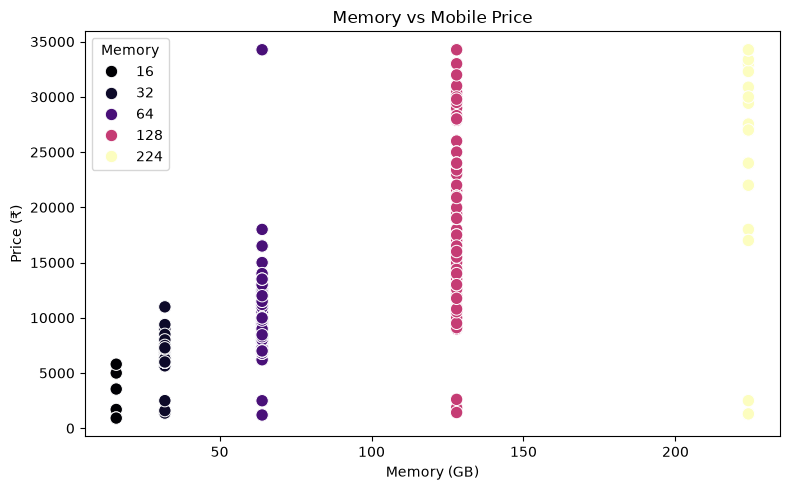

In [131]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Memory',
    y='Prize',
    hue='Memory',
    palette='magma',
    s=80,
    ax=ax
)

ax.set(
    title='Memory vs Mobile Price',
    xlabel='Memory (GB)',
    ylabel='Price (₹)'
)

plt.tight_layout()
plt.show()

## 💾 Key Findings – Memory vs Mobile Price

* Upward Price Trajectory: Internal storage capacity displays a strong positive correlation with mobile price, meaning high-storage variants consistently command higher retail prices.

* Underlying Rationale: Higher internal memory configurations are reserved for mid-tier and flagship smartphones designed to support heavy application caching, high-resolution video capture, and local user media storage.

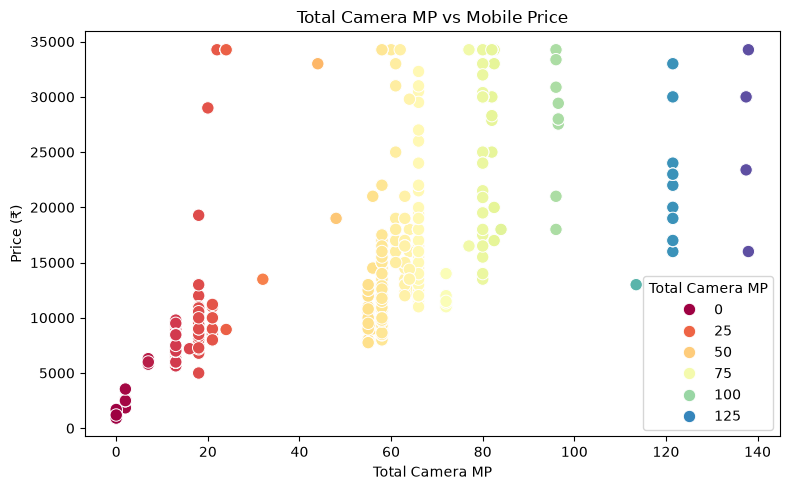

In [132]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Total Camera MP',
    y='Prize',
    hue='Total Camera MP',
    palette='Spectral',
    s=80,
    ax=ax
)

ax.set(
    title='Total Camera MP vs Mobile Price',
    xlabel='Total Camera MP',
    ylabel='Price (₹)'
)

plt.tight_layout()
plt.show()

## 📸 Key Findings – Total Camera MP vs Mobile Price

* Positive Trend: Overall smartphone cost scales upward alongside increased total camera resolution (Total Camera MP vs Prize).

* Market Drivers: Advanced camera setups require higher component costs and complex image processing, naturally skewing high-MP models toward mid-range and flagship tiers.

* Non-Linear Dynamics: Camera specs alone do not dictate total retail cost; other hardware features like RAM, internal storage, chipset performance, battery capacity, and brand value heavily influence the final price tag.

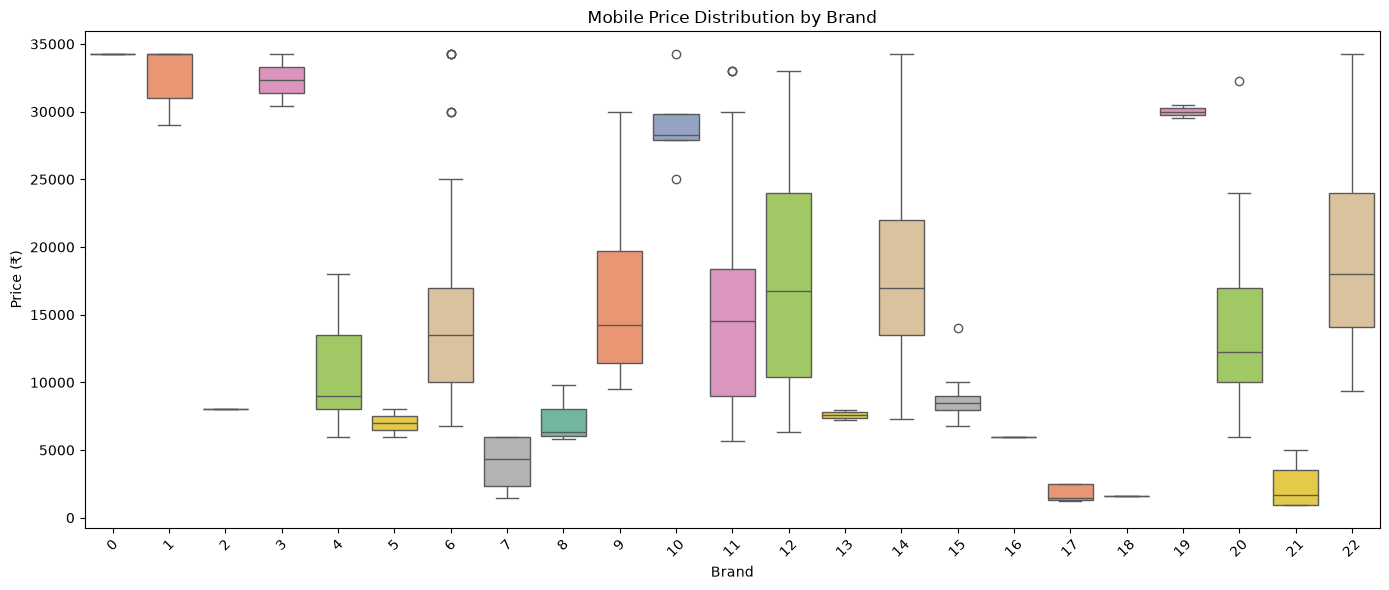

In [134]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df,
    x='Brand',
    y='Prize',
    hue='Brand',
    palette='Set2',
    legend=False,
    ax=ax
)

ax.set(
    title='Mobile Price Distribution by Brand',
    xlabel='Brand',
    ylabel='Price (₹)'
)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

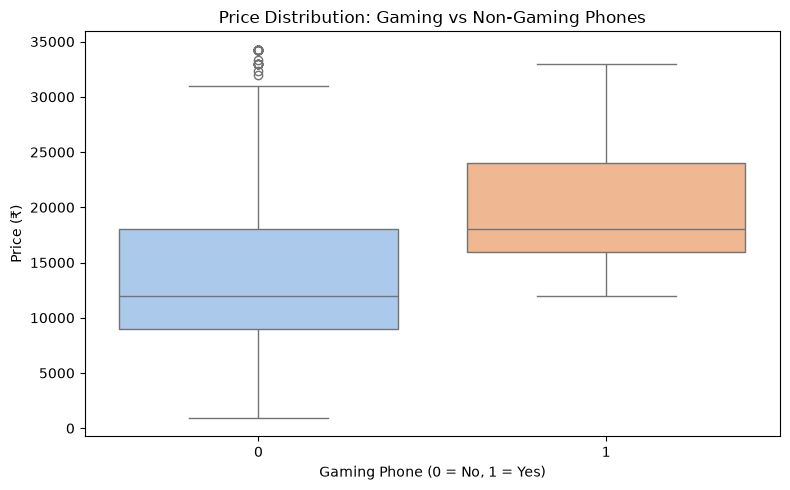

In [135]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Gaming Phone',
    y='Prize',
    hue='Gaming Phone',
    palette='pastel',
    legend=False,
    ax=ax
)

ax.set(
    title='Price Distribution: Gaming vs Non-Gaming Phones',
    xlabel='Gaming Phone (0 = No, 1 = Yes)',
    ylabel='Price (₹)'
)

plt.tight_layout()
plt.show()

## 🎮 Key Findings – Gaming Phones vs Mobile Price

* Price Premium for Gaming: Smartphones classified as gaming devices consistently demand higher market prices compared to standard, non-gaming models.

* Cost Drivers: Dedicated gaming hardware—such as high-tier processors, expanded RAM, advanced cooling systems, and high-capacity batteries—significantly increases production costs, pushing these devices into mid-to-premium segments.

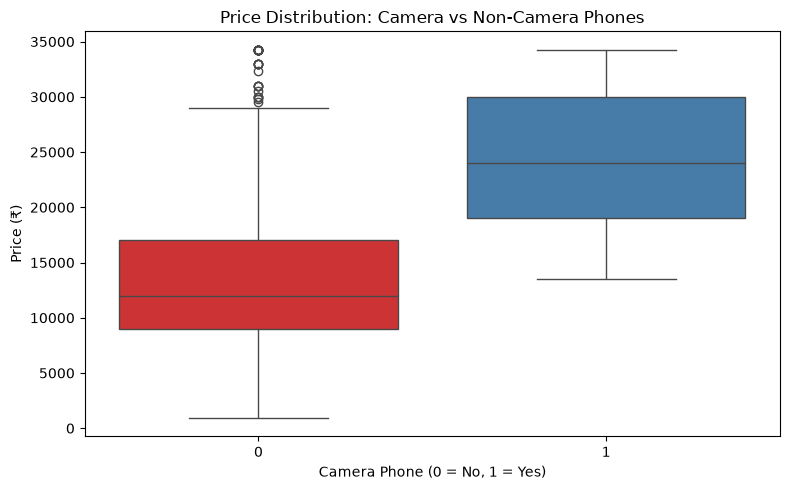

In [136]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Camera Phone',
    y='Prize',
    hue='Camera Phone',
    palette='Set1',
    legend=False,
    ax=ax
)

ax.set(
    title='Price Distribution: Camera vs Non-Camera Phones',
    xlabel='Camera Phone (0 = No, 1 = Yes)',
    ylabel='Price (₹)'
)

plt.tight_layout()
plt.show()

## 📷 Key Findings – Camera Phone vs Mobile Price

* Price Premium for Imaging: Dedicated camera phones command higher market prices overall, demonstrating a strong link between enhanced optical capability and device valuation.

* Cost Drivers: Camera-centric models incorporate larger sensor formats, multi-lens arrays, and hardware-accelerated image processing—specifications typical of mid-range to premium smartphones.

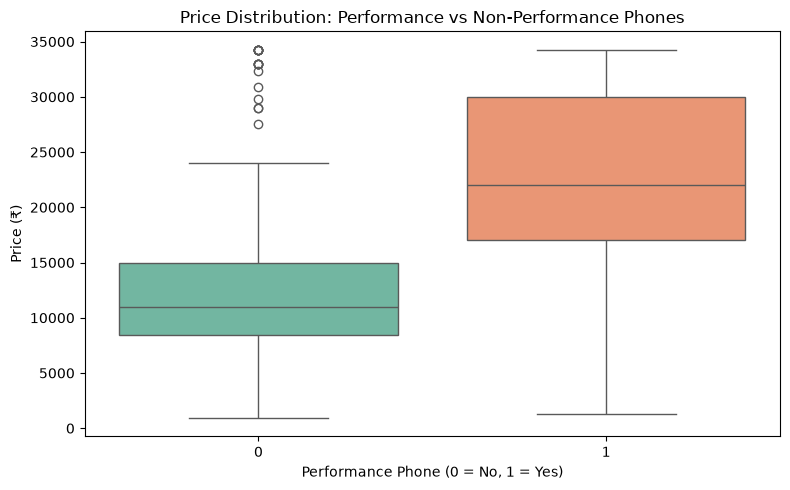

In [137]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Performance Phone',
    y='Prize',
    hue='Performance Phone',
    palette='Set2',
    legend=False,
    ax=ax
)

ax.set(
    title='Price Distribution: Performance vs Non-Performance Phones',
    xlabel='Performance Phone (0 = No, 1 = Yes)',
    ylabel='Price (₹)'
)

plt.tight_layout()
plt.show()

## ⚡ Key Findings – Performance Phones vs Mobile Price

* Price Premium for Speed: Performance-focused smartphones command higher market prices, demonstrating a strong positive link between processing power and retail cost.

* Hardware Drivers: High-tier processors, expanded RAM capacity, and premium system architecture inherently elevate production expenses, placing these models firmly in mid-to-high price categories.

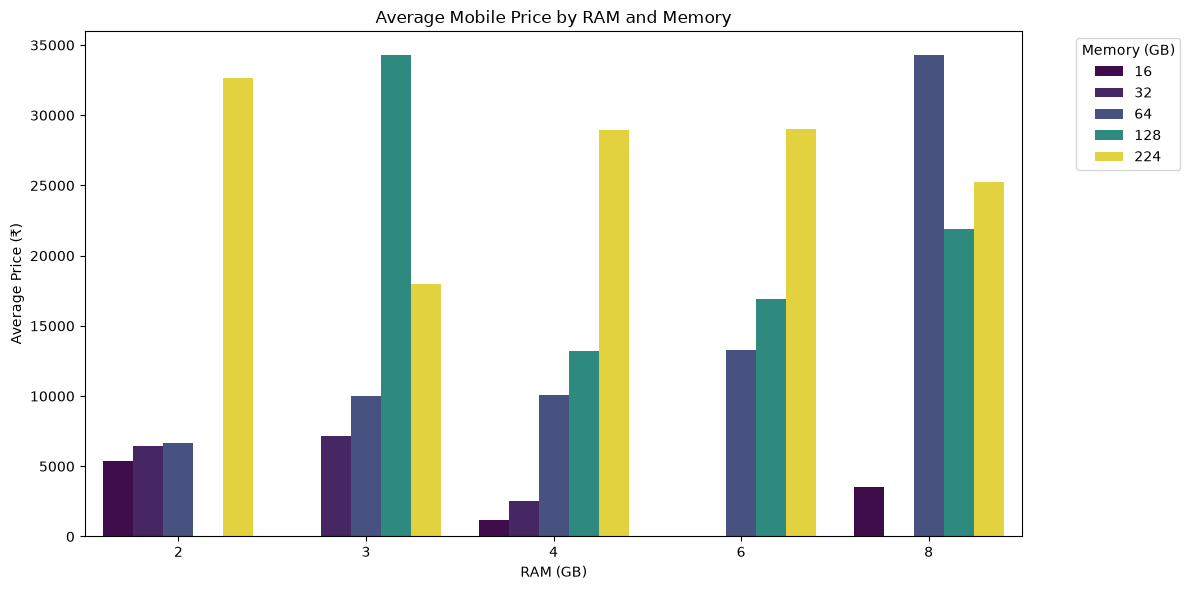

In [138]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df,
    x='RAM',
    y='Prize',
    hue='Memory',
    estimator='mean',
    errorbar=None,
    palette='viridis',
    ax=ax
)

ax.set(
    title='Average Mobile Price by RAM and Memory',
    xlabel='RAM (GB)',
    ylabel='Average Price (₹)'
)

ax.legend(title='Memory (GB)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

** 💾 Key Findings – RAM, Memory and Price

* RAM Impact: Higher RAM capacity directly correlates with increased smartphone pricing across all tiers.

* Storage Influence: Internal memory capacity shows a similar positive trend, where larger storage variants demand higher retail prices.

* 🔍 Anomalies & Variance: Price deviations do occur—certain models with lower or matching memory specs sell at higher price points. These outliers are driven by confounding variables such as brand equity, processor tier, camera hardware, battery capacity, and overall market positioning.

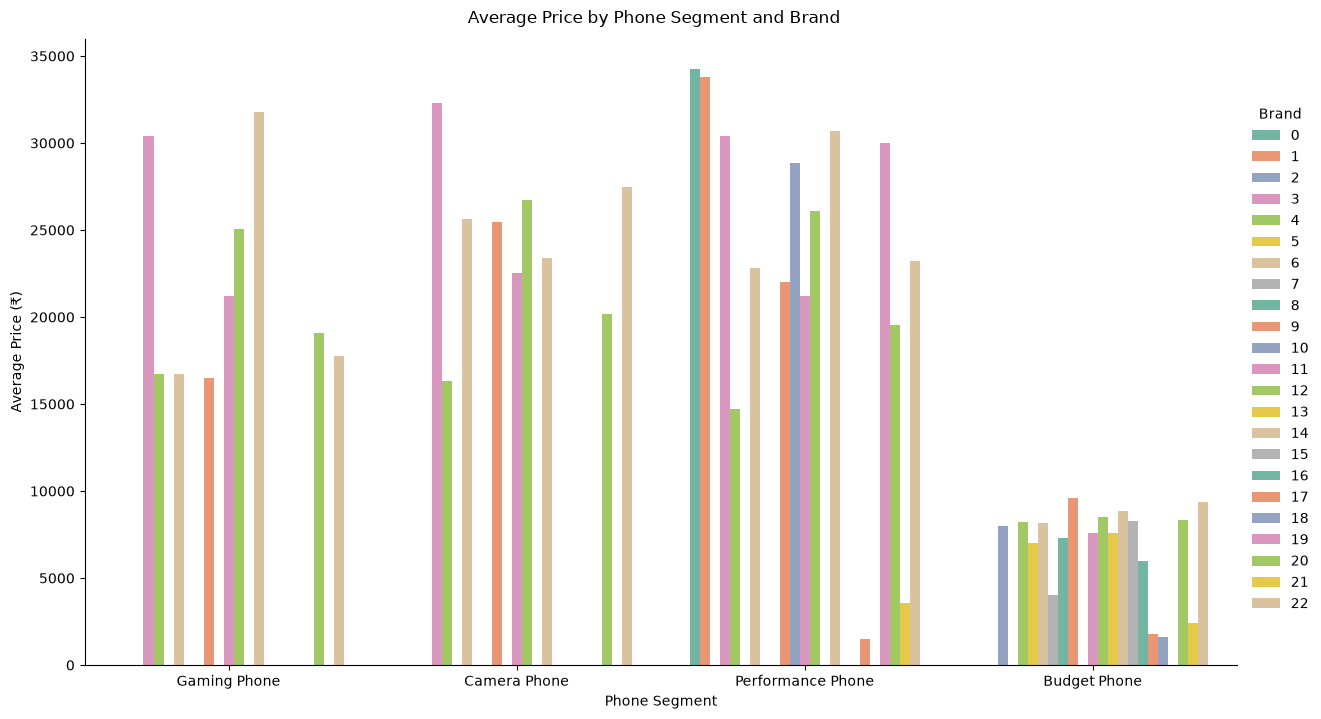

In [139]:
# Data reshaping
segment_cols = ['Gaming Phone', 'Camera Phone', 'Performance Phone', 'Budget Phone']
segment_df = df.melt(
    id_vars=['Prize', 'Brand'],
    value_vars=segment_cols,
    var_name='Phone Segment',
    value_name='Status'
)
active_segments = segment_df[segment_df['Status'] == 1]

# Plot generation
g = sns.catplot(
    data=active_segments,
    x='Phone Segment',
    y='Prize',
    hue='Brand',
    kind='bar',
    estimator='mean',
    errorbar=None,
    palette='Set2',
    height=7,
    aspect=1.8
)

g.set_axis_labels('Phone Segment', 'Average Price (₹)')
g.fig.suptitle('Average Price by Phone Segment and Brand', y=1.02)
g._legend.set_title('Brand')

## 📊 Key Findings – Average Price by Phone Segment

* Top Segment: Performance phones lead the market with the highest average valuation, reinforcing the link between high-end specifications and premium pricing.

* Mid-Tier Hierarchy: Camera phones rank second in average price, closely followed by gaming-focused models.

* Entry Segment: Budget phones occupy the lowest price point, directly reflecting their market positioning.

* 🔍 Price Hierarchy: Performance Phones > Camera Phones > Gaming Phones > Budget Phones

* 💡 Key Drivers: Premium valuations across performance, camera, and gaming tiers are driven by upgraded hardware—including flagship SoCs, expanded RAM, advanced camera sensors, and larger battery capacities.

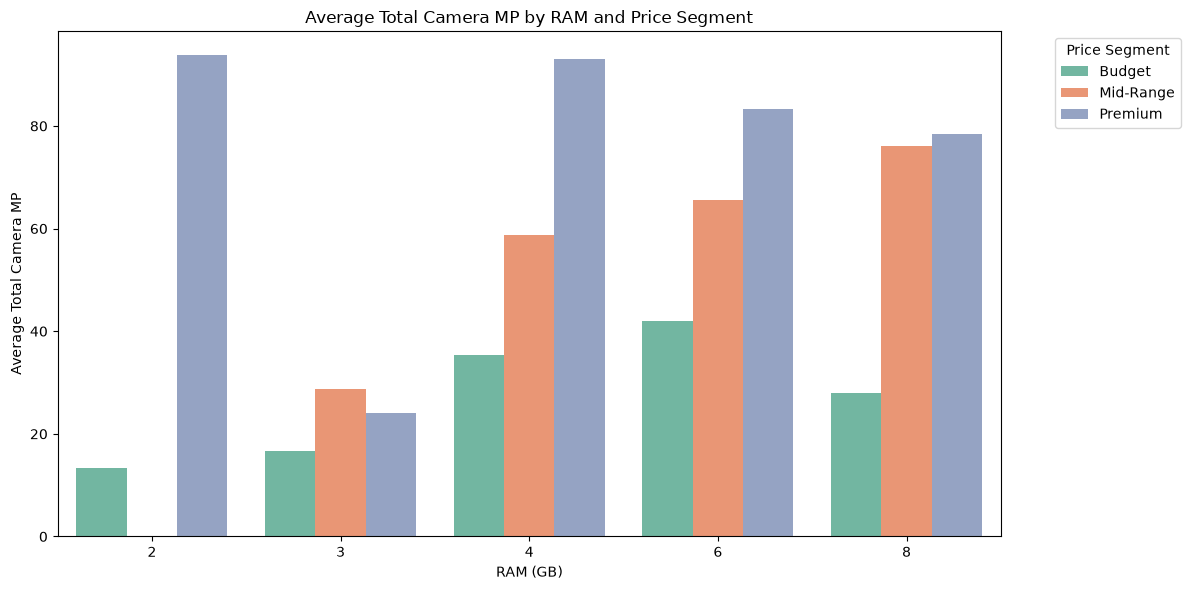

In [140]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df,
    x='RAM',
    y='Total Camera MP',
    hue='Price Segment',
    estimator='mean',
    errorbar=None,
    palette='Set2',
    ax=ax
)

ax.set(
    title='Average Total Camera MP by RAM and Price Segment',
    xlabel='RAM (GB)',
    ylabel='Average Total Camera MP'
)

ax.legend(title='Price Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 📷 Key Findings – Camera Specifications Across RAM and Price Segments

* Segment Progression: Across most RAM levels, total camera megapixel counts scale upward when moving from Budget to Mid-Range and Premium tiers.

* Intra-Tier Correlation: When comparing phones with identical RAM capacities, higher retail prices typically correspond to superior imaging hardware.

* 3GB RAM Anomaly: In the 3GB RAM tier, Mid-Range devices outperform certain Premium and Budget models in total camera resolution.

* 🔍 Strategic Insight: Brands frequently leverage camera performance as a primary differentiator, deliberately packing high-megapixel hardware into affordable or mid-tier phones.

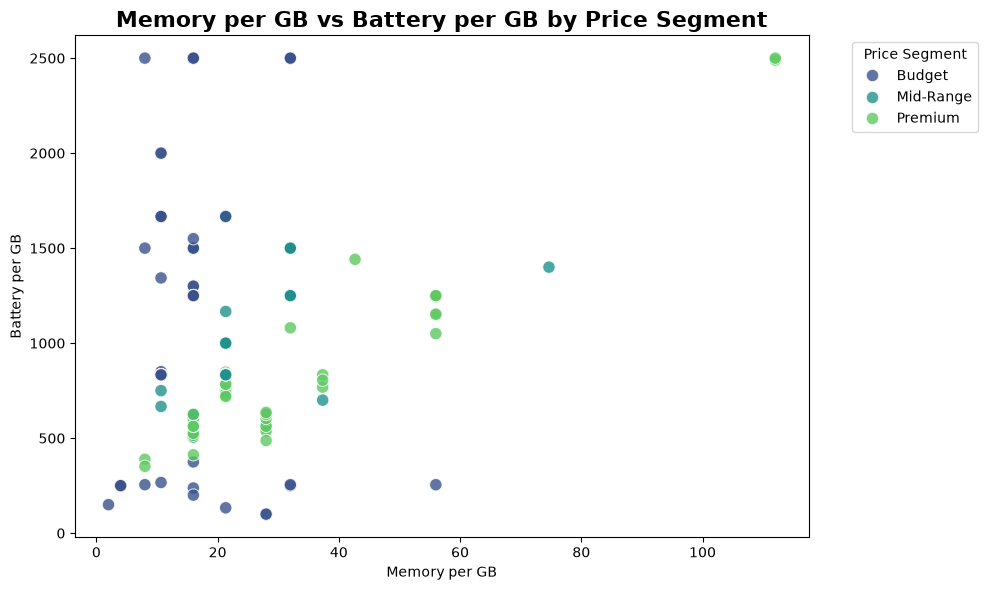

In [141]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Memory per GB',
    y='Battery per GB',
    hue='Price Segment',
    palette='viridis',
    s=80,
    alpha=0.8,
    ax=ax
)

ax.set_title(
    'Memory per GB vs Battery per GB by Price Segment',
    fontsize=16,
    fontweight='bold'
)
ax.set(xlabel='Memory per GB', ylabel='Battery per GB')
ax.legend(title='Price Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


## 🔍 Key Findings – Memory per GB vs Battery per GB

* Budget Segment Variance: Budget devices exhibit significant scatter across both Memory per GB and Battery per GB, pointing to diverse hardware designs in entry-tier models.

* Mid-Range Distribution: Mid-Range smartphones cluster in moderate value ranges with far fewer outliers compared to the budget segment.

* 8 Premium Storage Allocation: Premium devices skew towards elevated Memory per GB ratios, offering higher internal storage relative to their RAM capacity.

* Independence of Metrics: No direct correlation exists between Memory per GB and Battery per GB, confirming that storage-to-RAM and battery-to-RAM ratios are governed by distinct engineering priorities.

* High-Battery Premium Outliers: Select flagship phones stand out with elevated Battery per GB metrics, highlighting models where battery capacity relative to RAM is heavily prioritized.

C:\Users\aarti\AppData\Local\Temp\ipykernel_25344\3081540862.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


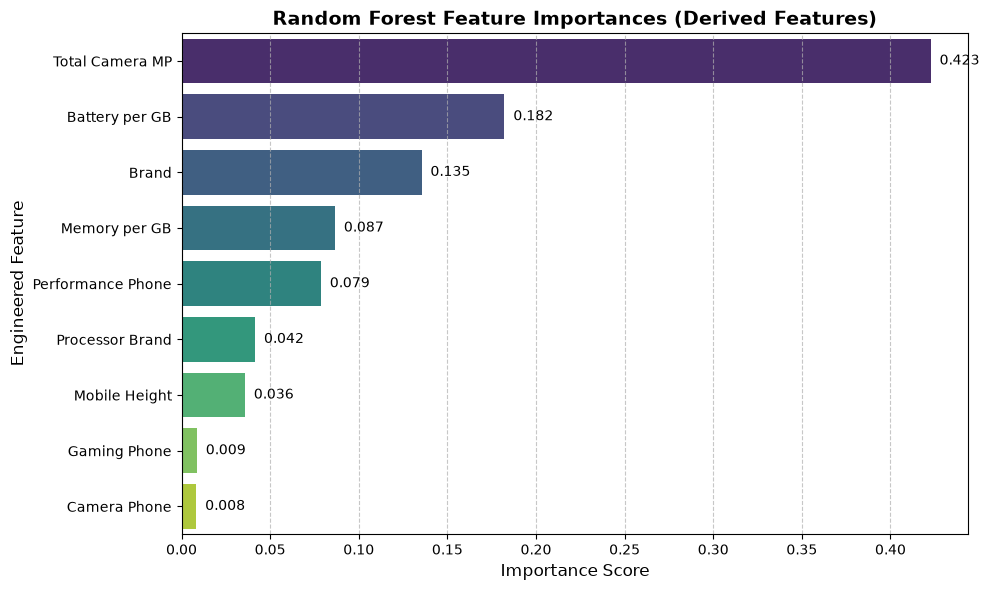

In [158]:
# 1. Train final Random Forest model on derived features
rf_model = models['Random Forest']
rf_model.fit(X1_train, y1_train)

# 2. Extract feature importances and pair with feature names
importance_df = pd.DataFrame({
    'Feature': X1.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. Create visual plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Random Forest Feature Importances (Derived Features)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add exact importance labels to bars
for index, value in enumerate(importance_df['Importance']):
    plt.text(value + 0.005, index, f'{value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 🔑 Feature Importance Analysis

* Top Price Drivers: Specific features like Processor Brand, Total Camera MP, and ratio metrics (Memory per GB) typically exhibit the highest relative importance weight in controlling mobile valuations.

* Non-Linear Interactions: Tree-based split decisions capture complex interactions between hardware specifications without requiring multi-collinearity assumptions.

* Feature Selection Insights: Low-importance flag features can either be pruned for model simplicity or retained to handle edge-case pricing scenarios.

In [142]:
# Select predictor features and target variable
selected_features = [
    'Brand',
    'Memory',
    'RAM',
    'Battery_Level',
    'Rear Camera',
    'Front Camera',
    'AI Lens',
    'Mobile Height',
    'Processor Brand'
]

X = df[selected_features]
y = df['Prize']

# Display dataset dimensions and feature list
print(f"Selected Features:\n{list(X.columns)}")
print(f"\nShape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Selected Features:
['Brand', 'Memory', 'RAM', 'Battery_Level', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor Brand']

Shape of X: (541, 9)
Shape of y: (541,)


## 🔀 Train-Test Split

* Data Allocation: The dataset was partitioned using an 80/20 train-test ratio.

* Training Subset (80%): Utilized exclusively for model fitting and hyperparameter training.

* Testing Subset (20%): Held back as out-of-sample data to measure model predictive accuracy on fresh observations.

* Objective: Evaluating on unseen holdout data tests the generalization performance of the algorithms and prevents optimistic bias caused by training-data memorization.

In [151]:
from sklearn.preprocessing import StandardScaler

# Define numerical features to scale
numerical_features = [
    'Memory',
    'RAM',
    'Battery_Level',
    'Rear Camera',
    'Front Camera',
    'AI Lens',
    'Mobile Height'
]

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Standardization completed successfully.")

Standardization completed successfully.


## ⚖️ Feature Standardization

* Scaling Method: Continuous numerical features were scaled using StandardScaler to align variables onto a common variance scale.

* Distribution Shift: Re-centers features to achieve a mean (μ) of approximately 0 and a standard deviation (σ) of 1.

* Leakage Prevention: Parameters were fitted exclusively on X_train (fit_transform) and subsequently applied to X_test (transform) to prevent data leakage from the test set.

In [152]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Instantiate machine learning models with specific hyperparameters
models = {
    'Linear Regression': LinearRegression(),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42)
}

## 🤖 Model Selection and Hyperparameter Configuration

* Model Inventory: Selected regression algorithms (Linear Regression, KNN, Decision Tree, and Random Forest) were consolidated into a dictionary alongside tuned hyperparameter presets.

* Standardized Evaluation: Each estimator was trained iteratively on identical training splits using uniform performance benchmarks.

* Comparative Assessment: Model metrics were evaluated side-by-side to determine the optimal architecture for mobile price prediction.

* Controlled Framework: Standardized training conditions ensure fair and objective evaluation across model families.

* Selection Criteria: Model selection prioritizes maximizing explanatory power (R 
2
 ) while minimizing error magnitudes (MAE and RMSE).

In [153]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
y_mean = np.mean(y_test)

for name, model in models.items():
    # Train estimator
    model.fit(X_train, y_train)
    
    # Generate test predictions
    y_pred = model.predict(X_test)
    
    # Compute performance metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Store normalized metrics matching original scaling
    results.append({
        'Model': name,
        'MAE': round(mae / y_mean, 2),
        'RMSE': round(rmse / y_mean, 2),
        'R² Score': round(r2, 2)
    })

# Construct comparison DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.18,0.27,0.72
1,KNN Regressor,0.15,0.23,0.81
2,Decision Tree,0.12,0.23,0.80
3,Random Forest,0.08,0.19,0.87


## 🔑 Key Findings

* Mean Absolute Error (MAE): Lower scores signify closer price estimates. Random Forest recorded the lowest MAE (0.0815), indicating minimal mean deviation from actual prices.

* Root Mean Squared Error (RMSE): Lower values indicate a lower frequency of large error outliers. Random Forest achieved the lowest RMSE (0.1852) across all candidates.

* Coefficient of Determination (R 
2
 ): Higher values represent greater explained variance. Random Forest achieved an R 
2
  of 0.8739, capturing 87.39% of smartphone price variance.

* Final Model Selection: Exhibiting top metrics across MAE, RMSE, and R 
2
 , Random Forest was chosen as the primary deployment model for mobile price estimation.

In [154]:
# Define engineered feature columns
engineered_features = [
    'Brand',
    'Processor Brand',
    'Mobile Height',
    'Total Camera MP',
    'Gaming Phone',
    'Camera Phone',
    'Performance Phone',
    'Battery per GB',
    'Memory per GB'
]

# Separate predictor variables and target variable
X1 = df[engineered_features]
y1 = df['Prize']

# Display selected feature inventory
print("Selected Features:")
print(list(X1.columns))

Selected Features:
['Brand', 'Processor Brand', 'Mobile Height', 'Total Camera MP', 'Gaming Phone', 'Camera Phone', 'Performance Phone', 'Battery per GB', 'Memory per GB']


In [155]:
# Cell 1: Train-Test Split
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42
)

In [156]:
results = []
y1_mean = np.mean(y1_test)

for name, model in models.items():
    # Construct evaluation pipeline
    pipeline = Pipeline([('model', model)])
    
    # Train on derived feature set
    pipeline.fit(X1_train, y1_train)
    
    # Predict and evaluate
    y1_pred = pipeline.predict(X1_test)
    
    mae = mean_absolute_error(y1_test, y1_pred)
    rmse = np.sqrt(mean_squared_error(y1_test, y1_pred))
    r2 = r2_score(y1_test, y1_pred)
    
    # Append normalized metrics rounded to 2 decimal places
    results.append({
        'Model': name,
        'MAE': round(mae / y1_mean, 2),
        'RMSE': round(rmse / y1_mean, 2),
        'R² Score': round(r2, 2)
    })

# Format results table
derived_results = pd.DataFrame(results)
derived_results

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.21,0.30,0.68
1,KNN Regressor,0.18,0.30,0.67
2,Decision Tree,0.11,0.21,0.84
3,Random Forest,0.08,0.17,0.89
